In [2]:
import numpy as np
import fitsio
from astropy.table import Table,vstack,join,unique
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import scienceplots
plt.style.use(['science','grid','notebook'])

from matplotlib.colors import LogNorm

from astropy.io import fits

In [3]:
DR1_SGC=Table(fitsio.FITS('../desi_dr1_SGC.fits')[1].read())
DR1_NGC=Table(fitsio.FITS('../desi_dr1_NGC.fits')[1].read())
DR1=vstack([DR1_NGC,DR1_SGC])
len(DR1)

5522353

In [4]:
#sanity checks
DR1_unique = unique(DR1,['TARGETID']) 
_, unique_indices = np.unique(DR1['TARGETID'], return_index=True)
print(f"Original DR1 length: {len(DR1)}")
print(f"DR1_unique length: {len(DR1_unique)}")
print(f"Unique indices shape: {unique_indices.shape}")
del(DR1_unique)


Original DR1 length: 5522353
DR1_unique length: 5522353
Unique indices shape: (5522353,)


In [5]:
north = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v10_flux_w1.fits')[1].read())
south = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/south_cuts_v10_flux_w1.fits')[1].read())
combined = vstack([north,south])

In [6]:
table_selection = Table(fitsio.FITS('../table_match_final.fits')[1].read())
common = join(
    table_selection,
    combined,
    keys=['BRICKID','OBJID','BRICKNAME'],
    join_type='inner'
)

In [7]:
coords_dr = SkyCoord(ra=DR1['RA']*u.deg, dec=DR1['DEC']*u.deg)
coords_legacy = SkyCoord(ra=common['RA_1']*u.deg, dec=common['DEC_1']*u.deg)
idx_legacy, idx_dr, sep2d, _ = coords_dr.search_around_sky(coords_legacy, 1.5*u.arcsec)
matched_dr = DR1[idx_dr]
matched_FP = common[idx_legacy]

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [8]:
matched_FP['MAG_R_1']
cols_to_remove = [col for col in matched_FP.colnames if col.endswith('_2')]
matched_FP.remove_columns(cols_to_remove)

cols_to_rename = {col: col[:-2] for col in matched_FP.colnames if col.endswith('_1')}
matched_FP.rename_columns(tuple(cols_to_rename.keys()), tuple(cols_to_rename.values()))

In [9]:
def two_d_hist(x,y):
    binx = np.linspace((min(x)), max(x), 50)
    biny = np.linspace((min(y)), max(y), 50)
    hist, xedges, yedges = np.histogram2d(x, y, bins=[binx, biny])
    return hist, xedges, yedges

/tmp/ipykernel_773775/3187994188.py:9: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0, 0.5, 'Photo Z (Legacy)')

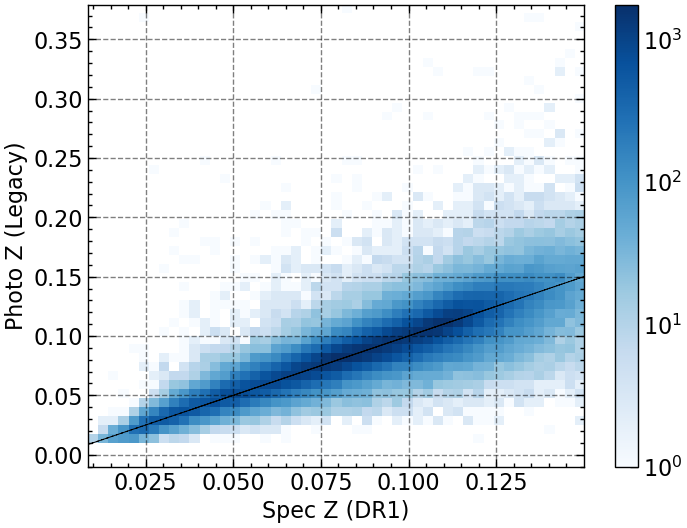

In [10]:
binx = np.linspace(min(matched_FP['Z_PHOT_MEDIAN']), max(matched_FP['Z_PHOT_MEDIAN']), 50)
biny = np.linspace(min(matched_dr['Z']), max(matched_dr['Z']), 50)
hist,xedges,yedges=np.histogram2d(matched_FP['Z_PHOT_MEDIAN'], matched_dr['Z'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='Blues',norm=LogNorm())

plt.plot(matched_FP['Z_PHOT_MEDIAN'],matched_FP['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel('Photo Z (Legacy)')

Text(0.5, 1.0, 'Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (FP sample)')

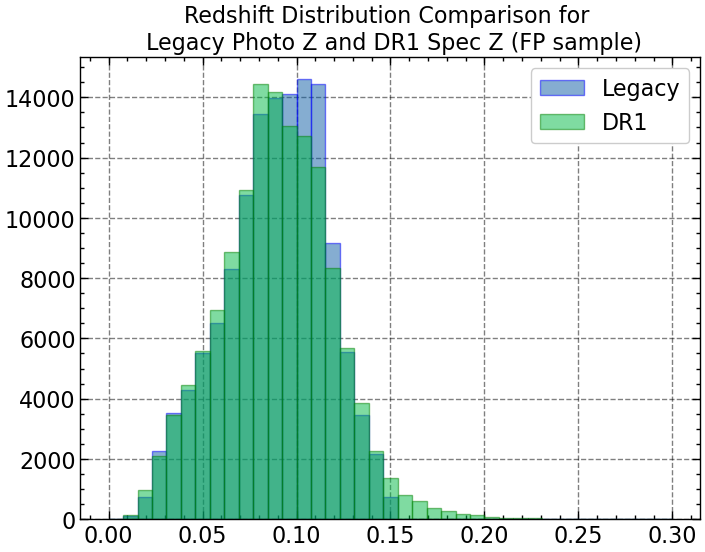

In [11]:
bins = np.linspace(0,0.3,40)
plt.hist(matched_FP['Z_PHOT_MEDIAN'], bins=bins, alpha=0.5, label='Legacy',edgecolor='blue')  
plt.hist(matched_dr['Z'], bins=bins, alpha=0.5, label='DR1',edgecolor='green')
plt.legend()
plt.title('Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (FP sample)')


In [12]:
def add_colors(table):
    MAG = {}
    FIBERMAG = {}
    MAG_NOEXT={}
    for i in ['G','R','Z','W1','W2','W3']:
        flux = np.array(table[f'FLUX_{i}'])
        trans = np.array(table[f'MW_TRANSMISSION_{i}'])
        frac = flux / trans
        mag = np.empty_like(frac)
        mag_noext = np.empty_like(frac)
        np.log10(flux, out=mag_noext, where=(frac > 0))
        np.log10(frac, out=mag, where=(frac > 0))
        MAG[i] = 22.5 - 2.5 * mag
        MAG_NOEXT[i] = 22.5 - 2.5 * mag_noext

    table['MAG_G'] = MAG['G']
    table['MAG_R'] = MAG['R']
    table['MAG_Z'] = MAG['Z']
    table['MAG_W1'] = MAG['W1']
    table['MAG_W2'] = MAG['W2']
    table['MAG_W3'] = MAG['W3']

    table['MAG_GR'] = table['MAG_G'] - table['MAG_R']
    table['MAG_RZ'] = table['MAG_R'] - table['MAG_Z']
    table['MAG_GZ'] = table['MAG_G'] - table['MAG_Z']
    table['MAG_W1W2'] = table['MAG_W1'] - table['MAG_W2']
    table['MAG_W2W3'] = table['MAG_W2'] - table['MAG_W3']
    table['MAG_W1W3'] = table['MAG_W1'] - table['MAG_W3']
    table['MAG_RW1'] = table['MAG_R'] - table['MAG_W1']
    table['MAG_RW2'] = table['MAG_R'] - table['MAG_W2']
    table['MAG_RW3'] = table['MAG_R'] - table['MAG_W3']
    table['MAG_GW1'] = table['MAG_G'] - table['MAG_W1']
    table['MAG_GW3'] = table['MAG_G'] - table['MAG_W3']
    table['MAG_GW2'] = table['MAG_G'] - table['MAG_W2']
    table['MAG_ZW1'] = table['MAG_Z'] - table['MAG_W1']
    table['MAG_ZW2'] = table['MAG_Z'] - table['MAG_W2']
    table['MAG_ZW3'] = table['MAG_Z'] - table['MAG_W3']
    return table

matched_FP = add_colors(matched_FP)

In [13]:
from catboost import CatBoostRegressor  
model = CatBoostRegressor() 
model.load_model("catboost_model_new.cbm")

y = matched_dr['Z']
feature_names = ['MAG_GR', 'MAG_G', 'MAG_RZ', 'MAG_R', 'MAG_RW1', 'MAG_ZW1', 'MAG_W1W2']

X = matched_FP[feature_names].to_pandas().to_numpy()
z_pred=model.predict(X)


/tmp/ipykernel_773775/2511889572.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label = 'CatBoost predicted')
/tmp/ipykernel_773775/2511889572.py:30: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label = 'Photo Z legacy')


Text(0.5, 0, 'Spec Z (DR1)')

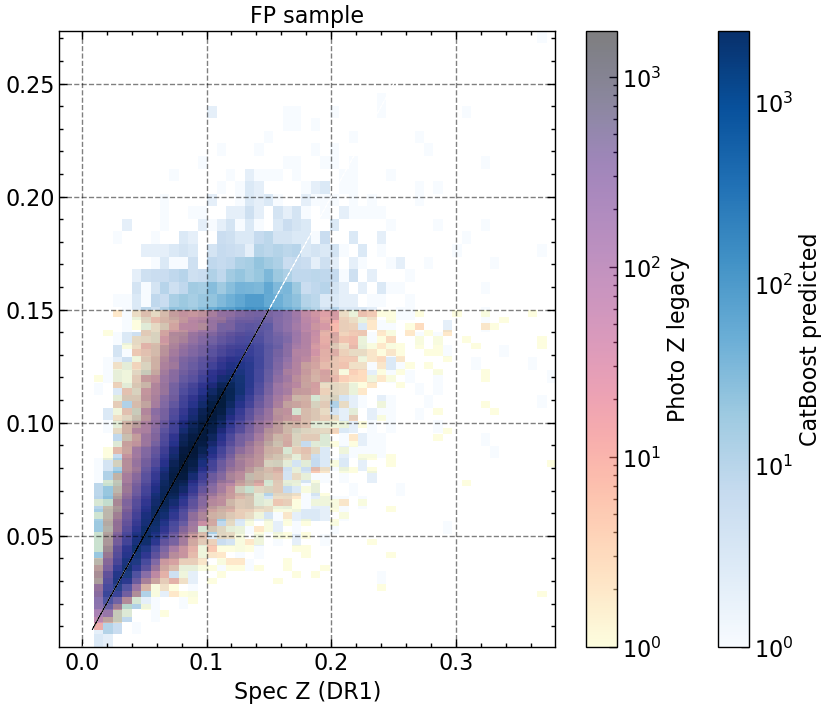

In [14]:
from matplotlib.colors import LogNorm

binx = np.linspace(min(matched_dr['Z']), 
                    max(matched_dr['Z']), 50)
biny = np.linspace(min(z_pred), 
                    max(z_pred), 50)
hist, xedges, yedges = np.histogram2d(matched_dr['Z'], 
                                        z_pred, 
                                        bins=(binx, biny))

# Log scale plot
plt.figure(figsize=(10, 8))
plt.imshow(hist.T, origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            aspect='auto', cmap='Blues', norm=LogNorm())
plt.plot(z_pred, z_pred, 'w--', lw=0.7)
plt.colorbar(label = 'CatBoost predicted')
plt.title('FP sample')
plt.xlabel('Z (DR1)')


biny = np.linspace(min(matched_FP['Z_PHOT_MEDIAN']), max(matched_FP['Z_PHOT_MEDIAN']), 50)
binx = np.linspace(min(matched_dr['Z']), max(matched_dr['Z']), 50)
hist,xedges,yedges=np.histogram2d(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r',norm=LogNorm(),alpha=0.5)

plt.plot(matched_FP['Z_PHOT_MEDIAN'],matched_FP['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar(label = 'Photo Z legacy')
plt.xlabel('Spec Z (DR1)')




Text(0.5, 1.0, 'FP sample')

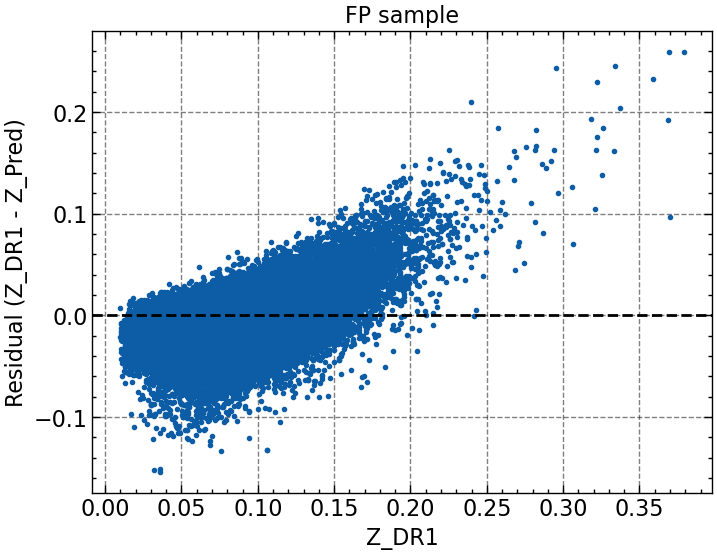

In [22]:
plt.plot(matched_dr['Z'],matched_dr['Z']-z_pred,'.')
plt.axhline(0,color='k',ls='--')
plt.xlabel('Z_DR1')
plt.ylabel('Residual (Z_DR1 - Z_Pred)')
plt.title('FP sample')

In [15]:
from scipy.stats import gaussian_kde

def kde2d(x, y, gridsize=100):
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    X, Y = np.mgrid[xmin:xmax:gridsize*1j, ymin:ymax:gridsize*1j]
    Z = gaussian_kde(np.vstack([x, y]))(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    return X, Y, Z
X1, Y1, Z1 = kde2d(matched_FP['Z_PHOT_MEDIAN'],matched_dr['Z'])
X2, Y2, Z2 = kde2d(z_pred,matched_dr['Z'])

In [35]:
loglevels= np.logspace(np.log10(10), np.log10(500), num=10)
loglevels = np.r_[0,loglevels]
loglevels

array([  0.        ,  10.        ,  15.44452105,  23.85332304,
        36.84031499,  56.89810203,  87.87639344, 135.72088083,
       209.61440008, 323.73940143, 500.        ])

In [36]:
levels = np.linspace(0, 500, 10)

/tmp/ipykernel_773775/2675365099.py:2: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=levels, norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/2675365099.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=levels, norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/2675365099.py:3: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Photo Z legacy')
/tmp/ipykernel_773775/2675365099.py:6: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(X2, Y2, Z2, cmap='Blues', linewidths=1.5,label='Catboost Z ',alpha=0.7,levels=levels,norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/2675365099.py:6: UserWarning:

(0.0, 0.2)

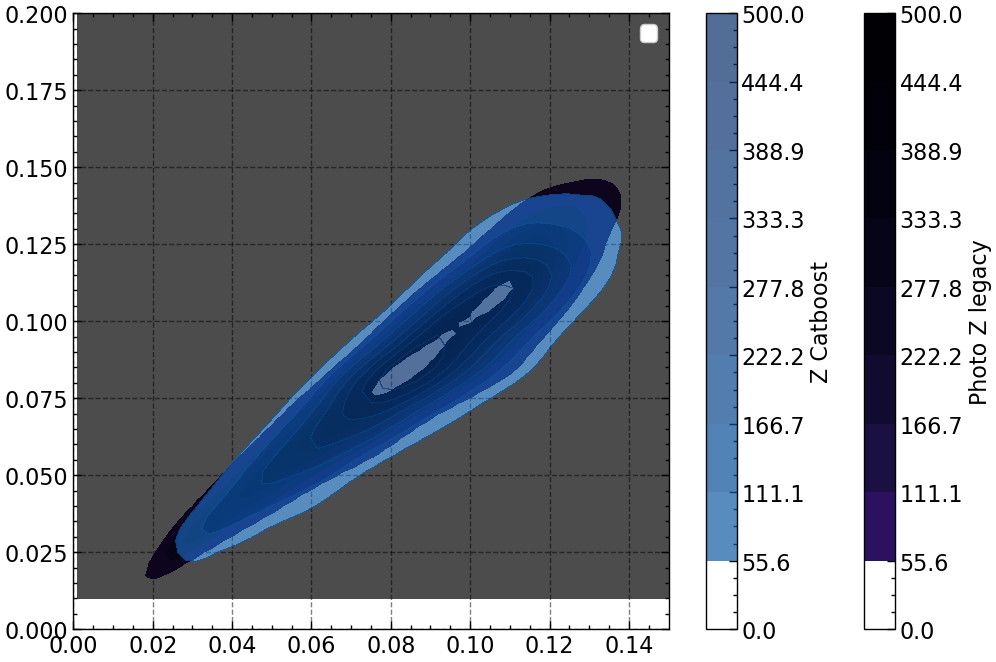

In [47]:
plt.figure(figsize=(12,8))
plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=levels, norm=LogNorm(vmin=0.01, vmax=500))
plt.colorbar(label='Photo Z legacy')


plt.contourf(X2, Y2, Z2, cmap='Blues', linewidths=1.5,label='Catboost Z ',alpha=0.7,levels=levels,norm=LogNorm(vmin=0.01, vmax=500))
plt.colorbar(label='Z Catboost')
plt.legend()
plt.xlim(0,0.15)
plt.ylim(0,0.2)

/tmp/ipykernel_773775/1455677100.py:2: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/1455677100.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/1455677100.py:3: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Photo Z legacy')
/tmp/ipykernel_773775/1455677100.py:6: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(X2, Y2, Z2, cmap='Blues', linewidths=1.5,label='Catboost Z ',alpha=0.7,levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/1455677100.py:6: UserW

(0.0, 0.2)

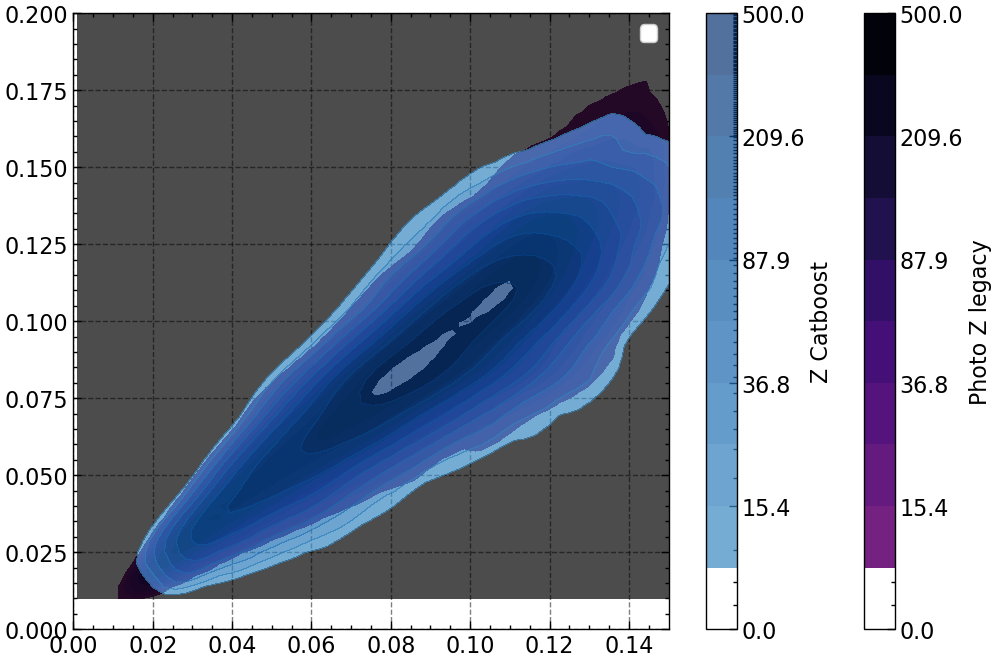

In [43]:
plt.figure(figsize=(12,8))
plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
plt.colorbar(label='Photo Z legacy')
1

plt.contourf(X2, Y2, Z2, cmap='Blues', linewidths=1.5,label='Catboost Z ',alpha=0.7,levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
plt.colorbar(label='Z Catboost')
plt.legend()
plt.xlim(0,0.15)
plt.ylim(0,0.2)

/tmp/ipykernel_720524/4041210135.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X2, Y2, Z2, colors='red', linewidths=1.5,label='Catboost Z ')
/tmp/ipykernel_720524/4041210135.py:3: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, Y1, Z1, colors='blue', linewidths=1.5,label='Legacy photo z ')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


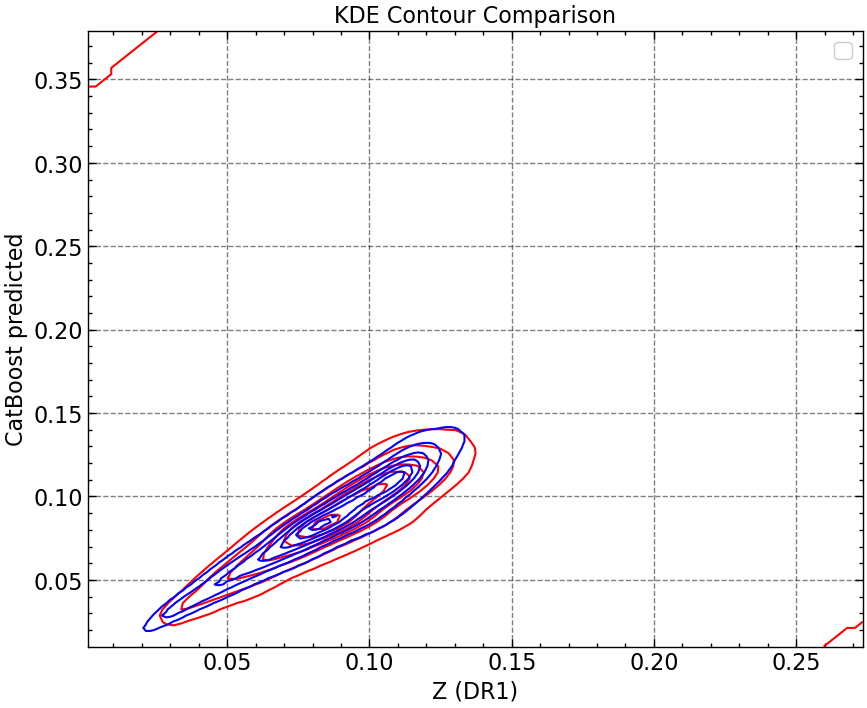

In [20]:
plt.figure(figsize=(10,8))
plt.contour(X2, Y2, Z2, colors='red', linewidths=1.5,label='Catboost Z ')
plt.contour(X1, Y1, Z1, colors='blue', linewidths=1.5,label='Legacy photo z ')

plt.xlabel('Z (DR1)')
plt.ylabel('CatBoost predicted')
plt.title('KDE Contour Comparison')
plt.legend()

/tmp/ipykernel_720524/25486365.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


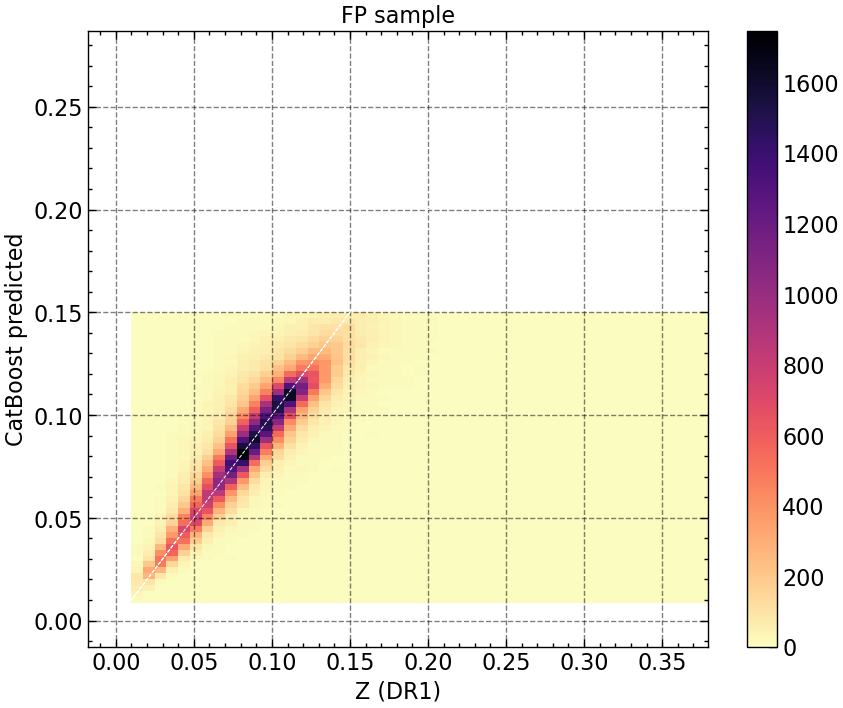

In [21]:
# Linear scale plot
plt.figure(figsize=(10, 8))
plt.imshow(hist.T, origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            aspect='auto', cmap='magma_r')
plt.plot(z_pred, z_pred, 'w--', lw=0.7)
plt.colorbar()
plt.title('FP sample')

plt.xlabel('Z (DR1)')
plt.ylabel('CatBoost predicted')
#plt.xlim(0, 0.15)
#plt.ylim(0, 0.25)
plt.show()


### For the Full intersection legacy and DR1 sample

In [23]:
DR1_north= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_north_v1_sep_1.fits')[1].read())
DR1_south= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_south_v1_sep_1.fits')[1].read())
DR1_full = vstack([DR1_north,DR1_south])
legacy_north = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_north_v1_sep_1.fits')[1].read())
legacy_south = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_south_v1_sep_1.fits')[1].read())
legacy_full = vstack([legacy_north,legacy_south])
mask1 = np.isfinite(DR1_full['Z'])
mask2  = DR1_full['Z']>0
mask3 = np.isfinite(legacy_full['Z_PHOT_MEDIAN'])
mask4 = legacy_full['Z_PHOT_MEDIAN']>0
DR1_full = DR1_full[mask1 & mask2 & mask4 &mask3]
legacy_full = legacy_full[mask1 & mask2 & mask4 &mask3]

In [24]:
legacy_full=add_colors(legacy_full)
feature_names = ['MAG_GR', 'MAG_G', 'MAG_RZ', 'MAG_R', 'MAG_RW1', 'MAG_ZW1', 'MAG_W1W2']
X_full = legacy_full[feature_names].to_pandas().to_numpy()
z_pred_full=model.predict(X_full)


In [26]:
legacy_full[['TYPE','SERSIC']]

TYPE,SERSIC
str3,float32
DEV,4.0
DEV,4.0
EXP,1.0
SER,1.9468104
SER,2.9227135
SER,2.097926
EXP,1.0
SER,2.4841363
SER,5.386053


/tmp/ipykernel_720524/1113800940.py:10: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0.5, 1.0, 'Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (for 1" separation)')

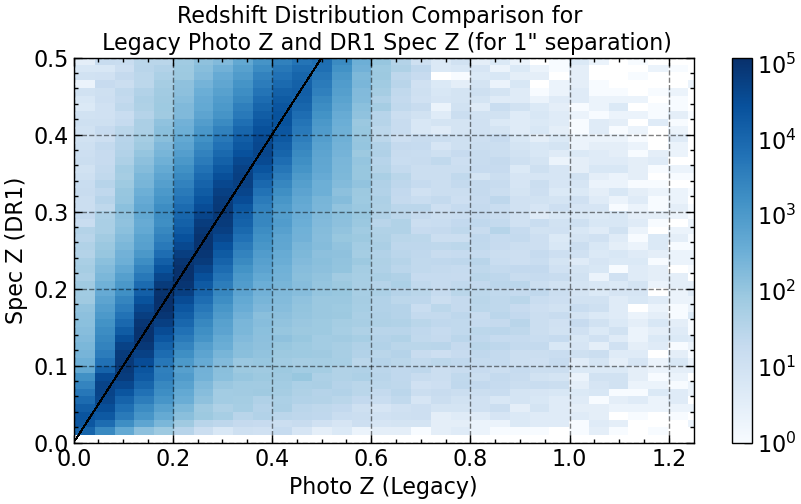

In [23]:
plt.figure(figsize=(10,5))
binx = np.linspace(min(legacy_full['Z_PHOT_MEDIAN']), max(legacy_full['Z_PHOT_MEDIAN']), 50)
biny = np.linspace(min(DR1_full['Z']), max(DR1_full['Z']), 50)
hist,xedges,yedges=np.histogram2d(legacy_full['Z_PHOT_MEDIAN'], DR1_full['Z'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='Blues',norm=LogNorm())

plt.plot(legacy_full['Z_PHOT_MEDIAN'],legacy_full['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar()
plt.xlim(0,1.25)
plt.ylim(0,0.5)
plt.ylabel('Spec Z (DR1)')

plt.xlabel('Photo Z (Legacy)')
plt.title('Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (for 1" separation)')

(array([  5141.,  42784.,  77556., 101799., 140333., 187188., 181031.,
        211242., 246701., 258229., 268779., 285164., 293485., 301647.,
        300305., 291110., 276608., 275358., 258591., 231294., 212802.,
        195797., 183825., 164655., 145641., 127978., 108376.,  92422.,
         77272.,  63600.,  49291.,  38732.,  20994.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.]),
 array([0.        , 0.01530612, 0.03061224, 0.04591837, 0.06122449,
        0.07653061, 0.09183673, 0.10714286, 0.12244898, 0.1377551 ,
        0.15306122, 0.16836735, 0.18367347, 0.19897959, 0.21428571,
        0.22959184, 0.24489796, 0.26020408, 0.2755102 , 0.29081633,
        0.30612245, 0.32142857, 0.33673469, 0.35204082, 0.36734694,
        0.38265306, 0.39795918, 0.41326531, 0.42857143, 0.44387755,
        0.45918367, 0.4744898 , 0.48979592, 0.50510204, 0.52040816,
        0.53571429, 0.551

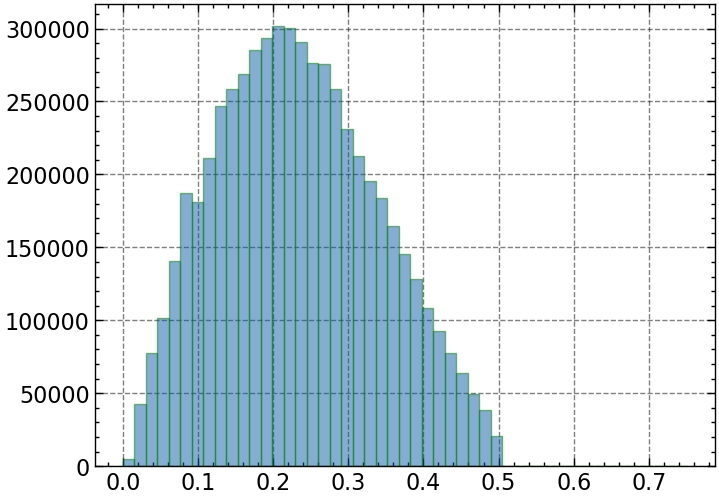

In [28]:
plt.hist(DR1_full['Z'], bins=bins, alpha=0.5, label='DR1',edgecolor='green')

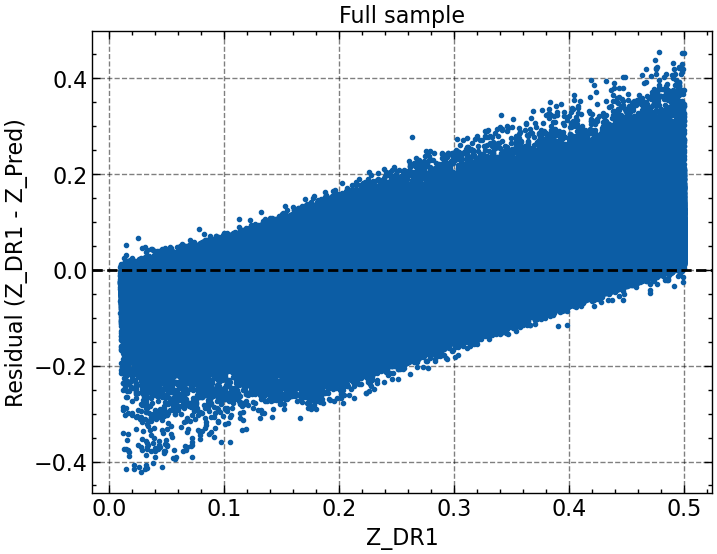

/tmp/ipykernel_773775/1528713378.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()
/tmp/ipykernel_773775/1528713378.py:30: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0, 0.5, "DR1_full['Z']-z_pred_full")

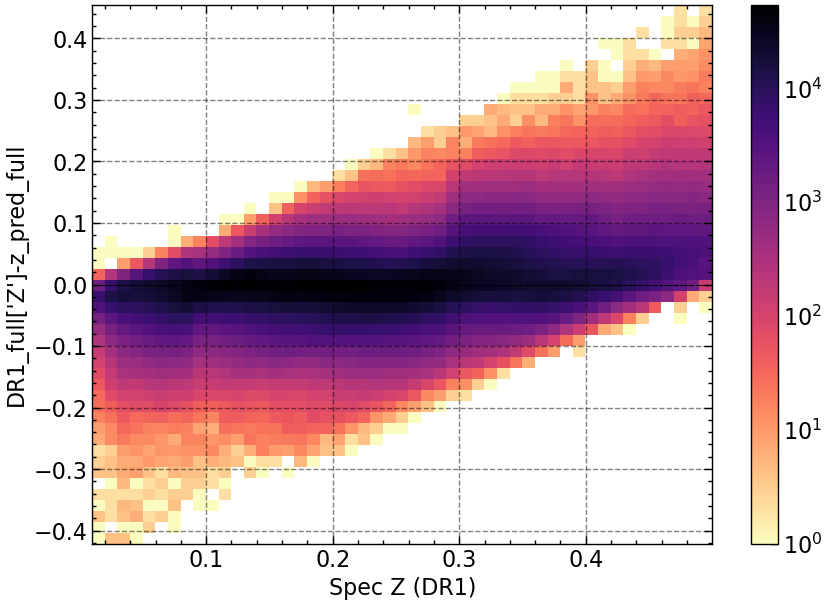

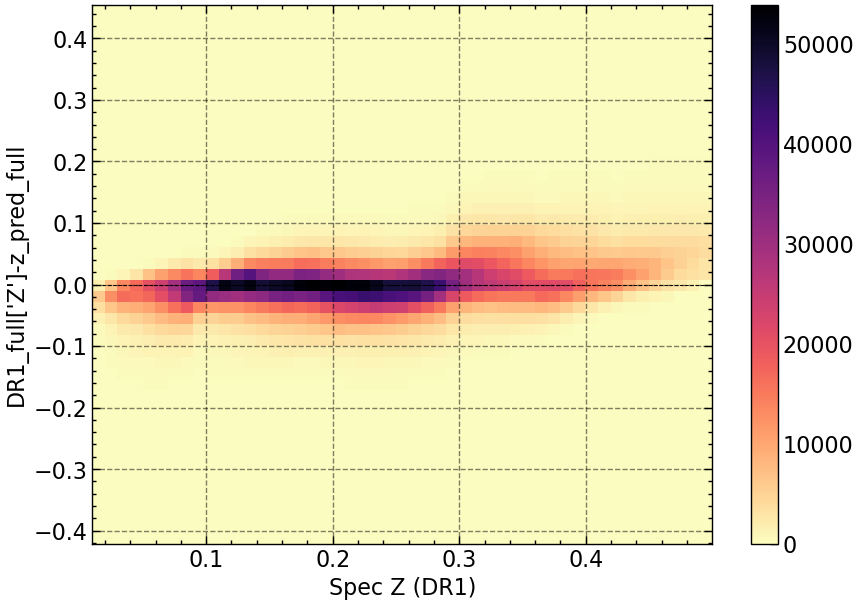

In [34]:
plt.plot(DR1_full['Z'],DR1_full['Z']-z_pred_full,'.')
plt.axhline(0,color='k',ls='--')
plt.xlabel('Z_DR1')
plt.ylabel('Residual (Z_DR1 - Z_Pred)')
plt.title('Full sample')
plt.show()

plt.figure(figsize=(10,7))
binx = np.linspace(min(DR1_full['Z']), max(DR1_full['Z']), 50)
biny = np.linspace(min(DR1_full['Z']-z_pred_full), max(DR1_full['Z']-z_pred_full), 50)
hist,xedges,yedges=np.histogram2d(DR1_full['Z'], DR1_full['Z']-z_pred_full, bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r',norm=LogNorm())

plt.axhline(0,color='k',ls='--',lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel('DR1_full[\'Z\']-z_pred_full')

plt.figure(figsize=(10,7))
binx = np.linspace(min(DR1_full['Z']), max(DR1_full['Z']), 50)
biny = np.linspace(min(DR1_full['Z']-z_pred_full), max(DR1_full['Z']-z_pred_full), 50)
hist,xedges,yedges=np.histogram2d(DR1_full['Z'], DR1_full['Z']-z_pred_full, bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r')

plt.axhline(0,color='k',ls='--',lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel('DR1_full[\'Z\']-z_pred_full')

In [ ]:
plt.plot(matched_dr['Z'],matched_dr['Z']-z_pred,'.')
plt.axhline(0,color='k',ls='--')
plt.xlabel('Z_DR1')
plt.ylabel('Residual (Z_DR1 - Z_Pred)')
plt.title('FP sample')

Text(0.5, 1.0, 'Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (for 1" separation)')

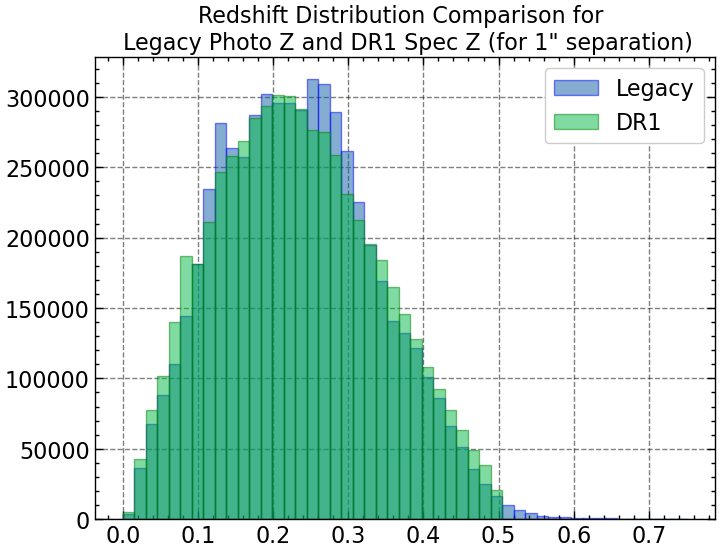

In [27]:
bins = np.linspace(0,0.75,50)
plt.hist(legacy_full['Z_PHOT_MEDIAN'], bins=bins, alpha=0.5, label='Legacy',edgecolor='blue')  
plt.hist(DR1_full['Z'], bins=bins, alpha=0.5, label='DR1',edgecolor='green')
plt.legend()
plt.title('Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (for 1" separation)')